In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
df = pd.read_csv(
    "../data/raw/DAPHNET/dataset/S01R01.txt", header=None, delim_whitespace=True
)
df.head(), df.shape

C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_37780\2916049526.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


(   0   1   2    3   4   5   6   7   8   9   10
 0  15  70  39 -970   0   0   0   0   0   0   0
 1  31  70  39 -970   0   0   0   0   0   0   0
 2  46  60  49 -960   0   0   0   0   0   0   0
 3  62  60  49 -960   0   0   0   0   0   0   0
 4  78  50  39 -960   0   0   0   0   0   0   0,
 (151987, 11))

In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,15,70,39,-970,0,0,0,0,0,0,0
1,31,70,39,-970,0,0,0,0,0,0,0
2,46,60,49,-960,0,0,0,0,0,0,0
3,62,60,49,-960,0,0,0,0,0,0,0
4,78,50,39,-960,0,0,0,0,0,0,0


1. DAPHNet dataset files exhibit minor structural variations across recordings, requiring dynamic column handling.


In [3]:
df.columns = [
    "time",
    "ankle_x",
    "ankle_y",
    "ankle_z",
    "thigh_x",
    "thigh_y",
    "thigh_z",
    "trunk_x",
    "trunk_y",
    "trunk_z",
    "label",
]

In [4]:
df.head()

,time,ankle_x,ankle_y,ankle_z,thigh_x,thigh_y,thigh_z,trunk_x,trunk_y,trunk_z,label
0,15,70,39,-970,0,0,0,0,0,0,0
1,31,70,39,-970,0,0,0,0,0,0,0
2,46,60,49,-960,0,0,0,0,0,0,0
3,62,60,49,-960,0,0,0,0,0,0,0
4,78,50,39,-960,0,0,0,0,0,0,0


In [6]:
df["label"].value_counts()

label
1    87655
0    59185
2     5147
Name: count, dtype: int64

0 → non-experimental / rest

1 → normal gait

2 → Freezing of Gait

This tells us:
How rare FoG is

How imbalanced the data is

Whether this subject even has FoG

🔴 Must be documented later


🧠 Very important observation already visible<br>
Look at this row:
`15  70  39 -970  0  0  0  0  0  0  0`

Notice:

Ankle values are non-zero<br>
Thigh + trunk are zero

This suggests:<br>

- Sensors may be inactive initially<br>
- Or subject is standing still<br>
- Or sensor dropout / task segmentation

🔴 Important methodological note

Raw recordings contain periods of inactivity and sensor silence, which must be handled carefully during windowing.


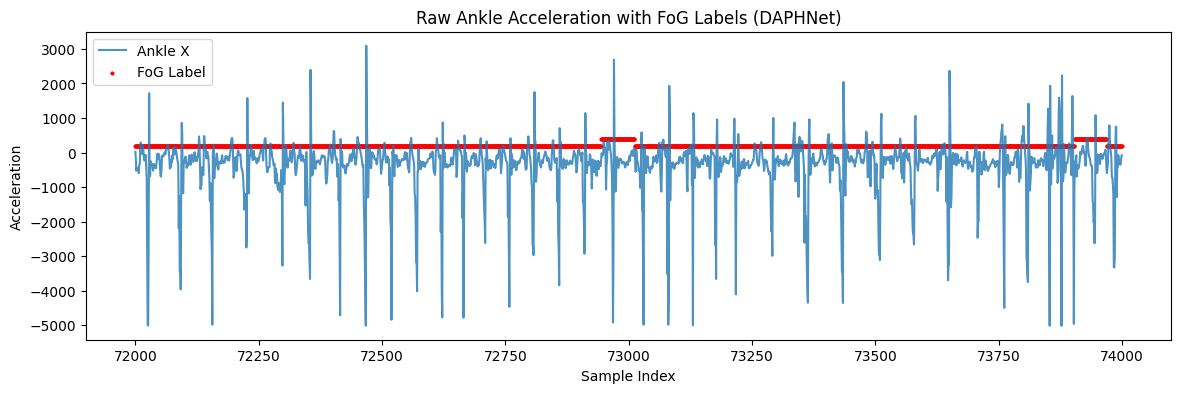

In [21]:
plt.figure(figsize=(14, 4))
plt.plot(df["ankle_x"][72000:74000], label="Ankle X", alpha=0.8)
plt.scatter(
    df.index[72000:74000],
    df["label"][72000:74000] * 200,
    color="red",
    s=4,
    label="FoG Label",
)
plt.legend()
plt.title("Raw Ankle Acceleration with FoG Labels (DAPHNet)")
plt.xlabel("Sample Index")
plt.ylabel("Acceleration")
plt.show()

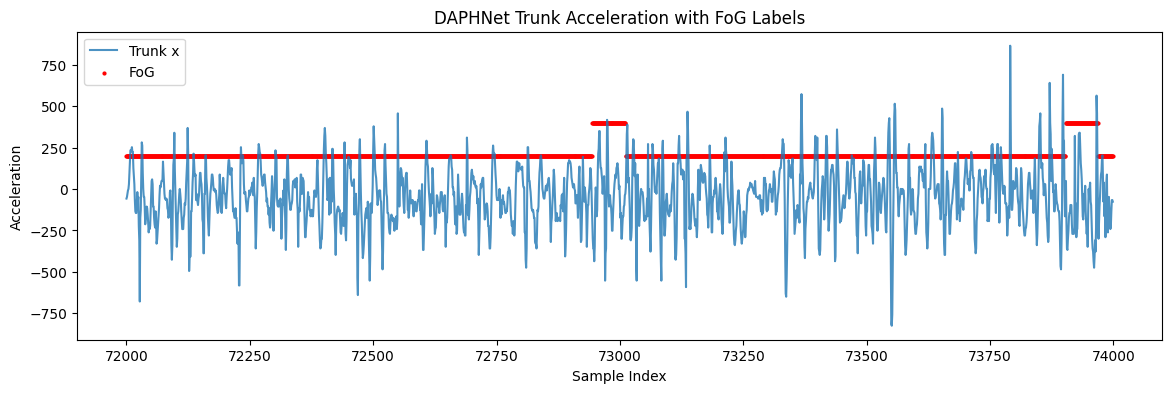

In [22]:
plt.figure(figsize=(14, 4))
plt.plot(df["trunk_x"][72000:74000], label="Trunk x", alpha=0.8)

plt.scatter(
    df.index[72000:74000],
    df["label"][72000:74000] * 200,
    color="red",
    s=4,
    label="FoG",
)

plt.legend()
plt.title("DAPHNet Trunk Acceleration with FoG Labels")
plt.xlabel("Sample Index")
plt.ylabel("Acceleration")
plt.show()

In [23]:
df[["ankle_x", "trunk_x"]].describe()

,ankle_x,trunk_x
count,151987.000000,151987.000000
mean,-167.635910,24.140637
std,480.466307,176.294999
min,-5020.000000,-4019.000000
25%,-262.000000,-58.000000
50%,-111.000000,9.000000
75%,0.000000,126.000000
max,5090.000000,4194.000000


In [14]:
df["label"].value_counts()

label
1    87655
0    59185
2     5147
Name: count, dtype: int64

In [16]:
df[df["label"] == 2]

,time,ankle_x,ankle_y,ankle_z,thigh_x,thigh_y,thigh_z,trunk_x,trunk_y,trunk_z,label
72944,1139765,-202,960,425,445,888,464,-203,885,252,2
72945,1139781,-20,1127,386,536,907,333,-300,923,252,2
72946,1139796,-80,1058,475,672,981,232,-359,990,135,2
72947,1139812,-90,1156,534,836,888,151,-359,990,-19,2
72948,1139828,-50,1343,485,1081,888,181,-436,933,-58,2
...,...,...,...,...,...,...,...,...,...,...,...
139051,2172687,1969,39,-1158,-2736,703,656,-19,961,592,2
139052,2172703,-121,313,1257,-2063,1620,444,0,1257,271,2
139053,2172718,313,2764,306,1354,1657,-666,58,1771,-300,2
139054,2172734,-424,2049,-277,2700,1203,-191,-135,1847,-310,2


🧠 Pause: Methodology thinking (VERY IMPORTANT)

We have already learned:

- Files are long, continuous recordings

- Labels are sample-level, not window-level

- Sensors may go silent

- Multi-sensor data exists but not always active

This directly affects:

- Windowing strategy

- Label assignment

- Feature extraction

- Cross-dataset fusion


In [8]:
(df[df["label"] == 2].shape[0] / df.shape[0]) * 100

3.3864738431576384

Key insights

- FoG samples are ~3.4% of the data
- This is severe class imbalance
- FoG is episodic and rare, not continuous

🔴 Must be documented in thesis

“FoG events constitute a small fraction of the total recorded samples, resulting in a highly imbalanced classification problem.”

This later justifies:

- Weighted loss functions
- Careful window labelling
- Why accuracy alone is misleading

---


Observations

- Large high-amplitude spikes in ankle acceleration
- FoG labels cluster around abrupt changes and irregular motion
- Long stretches of low-variance signal (likely rest or steady walking)

This visually confirms:

- FoG is not random noise
- It is associated with instability and oscillatory behaviour
- There are inactive / non-walking segments

🔴 This plot becomes Figure 3.1

---


3️⃣ Critical methodological decision (VERY IMPORTANT)

Based on what we’ve seen, we will NOT:

❌ Train directly on raw samples
❌ Treat labels as balanced
❌ Ignore label 0 blindly

Instead, we will:

- Window the data
- Collapse labels into binary later (FoG vs Non-FoG)
- Carefully decide how to treat label 0

This becomes a design choice, not a shortcut.


---

Across your 3 datasets, we have:

| Data Type         | DAPHNet | Kaggle TLVMC | Figshare |
| ----------------- | ------- | ------------ | -------- |
| Accelerometer     | ✅      | ✅           | ✅       |
| Gyroscope         | ❌      | ❌           | ✅       |
| Video             | ❌      | ❌           | ✅       |
| Clinical metadata | ❌      | Limited      | Limited  |
| FoG labels        | ✅      | ✅           | ✅       |

_👉 Accelerometer data is the only universally available modality._


In [9]:
import glob

files = sorted(glob.glob("../data/raw/DAPHNET/dataset/S*.txt"))
files[:5]

['../data/raw/DAPHNET/dataset\\S01R01.txt',
 '../data/raw/DAPHNET/dataset\\S01R02.txt',
 '../data/raw/DAPHNET/dataset\\S02R01.txt',
 '../data/raw/DAPHNET/dataset\\S02R02.txt',
 '../data/raw/DAPHNET/dataset\\S03R01.txt']

In [10]:
sample_files = files

---

Dataset-specific parsing logic was implemented to ensure consistent handling of raw recordings.


In [11]:
def load_daphnet_file(path):
    df = pd.read_csv(path, sep=r"\s+", header=None)
    df.columns = [
        "time",
        "ankle_x",
        "ankle_y",
        "ankle_z",
        "thigh_x",
        "thigh_y",
        "thigh_z",
        "trunk_x",
        "trunk_y",
        "trunk_z",
        "label",
    ]
    return df

In [12]:
summary = []

for f in sample_files:
    df = load_daphnet_file(f)
    counts = df["label"].value_counts(normalize=True)
    summary.append(
        {
            "file": f,
            "non_exp_%": counts.get(0, 0) * 100,
            "gait_%": counts.get(1, 0) * 100,
            "fog_%": counts.get(2, 0) * 100,
            "total_samples": len(df),
        }
    )

summary_df = pd.DataFrame(summary)
summary_df

,file,non_exp_%,gait_%,fog_%,total_samples
0,../data/raw/DAPHNET/dataset\S01R01.txt,38.940830,57.672696,3.386474,151987
1,../data/raw/DAPHNET/dataset\S01R02.txt,44.714464,52.315961,2.969575,52095
2,../data/raw/DAPHNET/dataset\S02R01.txt,64.717961,30.407519,4.874519,72561
3,../data/raw/DAPHNET/dataset\S02R02.txt,27.535278,63.460316,9.004406,89645
4,../data/raw/DAPHNET/dataset\S03R01.txt,36.970664,51.909286,11.120050,144190
5,../data/raw/DAPHNET/dataset\S03R02.txt,57.082065,36.970650,5.947284,38774
6,../data/raw/DAPHNET/dataset\S03R03.txt,69.942649,30.057351,0.000000,70269
7,../data/raw/DAPHNET/dataset\S04R01.txt,32.316322,67.683678,0.000000,195737
8,../data/raw/DAPHNET/dataset\S05R01.txt,38.259651,45.948528,15.791821,109886
9,../data/raw/DAPHNET/dataset\S05R02.txt,34.566137,52.513251,12.920612,100746


In [13]:
summary_df.describe()

,non_exp_%,gait_%,fog_%,total_samples
count,17.000000,17.000000,17.000000,17.000000
mean,43.830002,50.514194,5.655805,112816.882353
std,13.362853,13.303751,4.914619,53547.470057
min,26.166692,26.667594,0.000000,38774.000000
25%,35.369767,44.863997,2.656203,70269.000000
50%,38.805511,52.513251,4.788085,109886.000000
75%,55.136003,57.672696,9.414375,151987.000000
max,69.942649,73.833308,15.791821,195737.000000


In [14]:
for f in sample_files:
    df = load_daphnet_file(f)
    print(f)
    print(df[["ankle_x", "ankle_y", "ankle_z"]].describe().loc[["min", "max"]])
    print("-" * 50)

../data/raw/DAPHNET/dataset\S01R01.txt
     ankle_x  ankle_y  ankle_z
min  -5020.0  -4843.0  -4960.0
max   5090.0   4813.0   4752.0
--------------------------------------------------
../data/raw/DAPHNET/dataset\S01R02.txt
     ankle_x  ankle_y  ankle_z
min  -5010.0  -4431.0  -4970.0
max  22596.0  22596.0  13144.0
--------------------------------------------------
../data/raw/DAPHNET/dataset\S02R01.txt
     ankle_x  ankle_y  ankle_z
min -10277.0  -2637.0 -23294.0
max  25601.0  11777.0  19202.0
--------------------------------------------------
../data/raw/DAPHNET/dataset\S02R02.txt
     ankle_x  ankle_y  ankle_z
min -12283.0 -20731.0  -8704.0
max  30723.0  22632.0  24319.0
--------------------------------------------------
../data/raw/DAPHNET/dataset\S03R01.txt
     ankle_x  ankle_y  ankle_z
min  -5010.0  -4911.0 -17918.0
max  25345.0  22596.0  22596.0
--------------------------------------------------
../data/raw/DAPHNET/dataset\S03R02.txt
     ankle_x  ankle_y  ankle_z
min -12739.0  -

📘 Comparative Analysis of Sensor Placement and Fusion Strategy

A critical aspect of this study involves ensuring compatibility across datasets that employ different sensor configurations. The DAPHNet dataset utilises multiple sensor placements, including ankle, thigh, and trunk-mounted accelerometers, whereas the TLVMC dataset relies on a single lower-back accelerometer. To enable meaningful cross-dataset learning and feature-level fusion, it is necessary to identify a common and comparable sensor representation.

An exploratory analysis was conducted to compare the characteristics of ankle-mounted and trunk-mounted accelerometer signals within the DAPHNet dataset. Statistical evaluation revealed that ankle signals exhibit significantly higher variability (standard deviation ≈ 480) compared to trunk signals (standard deviation ≈ 176). Additionally, ankle signals demonstrated a wider dynamic range and pronounced spiky behaviour, indicative of fine-grained step-level motion. In contrast, trunk signals were comparatively smoother and more stable, reflecting overall body movement and postural dynamics.

Visual inspection of the signals further supported these observations. While ankle signals contained high-frequency fluctuations that made direct interpretation of Freezing of Gait (FoG) events more challenging, trunk signals displayed clearer patterns of irregularity during FoG episodes. These irregularities, although less extreme in amplitude, were consistently aligned with annotated FoG regions, suggesting that trunk-mounted sensors are capable of capturing FoG-related movement disruptions effectively.

Given that the TLVMC dataset employs a lower-back sensor, which is biomechanically analogous to the trunk sensor in the DAPHNet dataset, trunk signals were selected as the primary modality for cross-dataset alignment. This decision ensures that both datasets represent similar aspects of human movement, namely balance, posture, and overall gait stability, rather than fine-grained limb motion.

Accordingly, the proposed fusion strategy avoids raw signal concatenation, which would be inappropriate due to differences in sensor placement and biomechanics. Instead, a feature-level fusion approach is adopted, wherein semantically consistent gait features (e.g., statistical, frequency-domain, and stability-related features) are extracted from trunk-aligned signals across datasets. This enables the model to learn location-invariant representations of FoG while maintaining compatibility between datasets.

This design choice is further supported by the observation that trunk signals exhibit lower noise and more stable distributions, which are conducive to robust feature extraction and generalisable model learning. Consequently, ankle and thigh sensor data from the DAPHNet dataset are not utilised in the fusion stage, although they may be explored in future work for multi-sensor extensions


In [16]:
folder_path = r"../data/raw/DAPHNET/dataset"

all_durations = []

for file in os.listdir(folder_path):
    if file.endswith(".txt"):
        df = pd.read_csv(
            os.path.join(folder_path, file), delim_whitespace=True, header=None
        )

        # label column is last column
        labels = df.iloc[:, -1].values

        fog_indices = np.where(labels == 2)[0]
        segments = np.split(fog_indices, np.where(np.diff(fog_indices) != 1)[0] + 1)

        durations = [len(seg) for seg in segments if len(seg) > 0]
        all_durations.extend(durations)

print("Total FoG episodes:", len(all_durations))
print("Mean duration:", np.mean(all_durations))
print("Max duration:", np.max(all_durations))
print("Min duration:", np.min(all_durations))

C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\158649499.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\158649499.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\158649499.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\158649499.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\15864949

Total FoG episodes: 237
Mean duration: 467.44725738396625
Max duration: 2594
Min duration: 28


In [28]:
DAPHNET_PATH = r"../data/raw/DAPHNET/dataset"

results = []
print(os.listdir(DAPHNET_PATH))
for file in os.listdir(DAPHNET_PATH):
    if file.endswith(".txt"):
        df = pd.read_csv(
            os.path.join(DAPHNET_PATH, file), delim_whitespace=True, header=None
        )

        # Split labels
        labels = df.iloc[:, -1]

        # Sensor mappings
        sensors = {"ankle": [1, 2, 3], "thigh": [4, 5, 6], "trunk": [7, 8, 9]}

        axes = ["x", "y", "z"]

        for sensor_name, cols in sensors.items():
            for i, col in enumerate(cols):
                axis = axes[i]

                fog_values = df.loc[labels == 2, col]
                nonfog_values = df.loc[labels == 1, col]

                results.append(
                    {
                        "file": file,
                        "sensor": sensor_name,
                        "axis": axis,
                        "fog_std": fog_values.std(),
                        "nonfog_std": nonfog_values.std(),
                    }
                )

per_file_df = pd.DataFrame(results)

per_file_df

['S01R01.txt', 'S01R02.txt', 'S02R01.txt', 'S02R02.txt', 'S03R01.txt', 'S03R02.txt', 'S03R03.txt', 'S04R01.txt', 'S05R01.txt', 'S05R02.txt', 'S06R01.txt', 'S06R02.txt', 'S07R01.txt', 'S07R02.txt', 'S08R01.txt', 'S09R01.txt', 'S10R01.txt']


C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\2921547509.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\2921547509.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\2921547509.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\2921547509.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\2921

,file,sensor,axis,fog_std,nonfog_std
0,S01R01.txt,ankle,x,630.971995,569.142861
1,S01R01.txt,ankle,y,451.135889,348.742417
2,S01R01.txt,ankle,z,341.420497,287.496320
3,S01R01.txt,thigh,x,561.022093,521.717370
4,S01R01.txt,thigh,y,242.865692,359.891639
...,...,...,...,...,...
148,S10R01.txt,thigh,y,NaN,379.790919
149,S10R01.txt,thigh,z,NaN,281.065832
150,S10R01.txt,trunk,x,NaN,148.095081
151,S10R01.txt,trunk,y,NaN,396.730976


In [33]:
per_file_df["fog_higher"] = per_file_df["fog_std"] > per_file_df["nonfog_std"]

summary = per_file_df.groupby(["sensor", "axis"])["fog_higher"].mean()

summary

sensor  axis
ankle   x       0.411765
        y       0.470588
        z       0.352941
thigh   x       0.352941
        y       0.000000
        z       0.470588
trunk   x       0.411765
        y       0.411765
        z       0.176471
Name: fog_higher, dtype: float64

In [31]:
all_fog = {
    ("ankle", "x"): [],
    ("ankle", "y"): [],
    ("ankle", "z"): [],
    ("thigh", "x"): [],
    ("thigh", "y"): [],
    ("thigh", "z"): [],
    ("trunk", "x"): [],
    ("trunk", "y"): [],
    ("trunk", "z"): [],
}

all_nonfog = {key: [] for key in all_fog.keys()}

for file in os.listdir(DAPHNET_PATH):
    if file.endswith(".txt"):
        df = pd.read_csv(
            os.path.join(DAPHNET_PATH, file), delim_whitespace=True, header=None
        )

        labels = df.iloc[:, -1]

        sensors = {"ankle": [1, 2, 3], "thigh": [4, 5, 6], "trunk": [7, 8, 9]}

        axes = ["x", "y", "z"]

        for sensor_name, cols in sensors.items():
            for i, col in enumerate(cols):
                axis = axes[i]

                key = (sensor_name, axis)

                all_fog[key].extend(df.loc[labels == 2, col].values)
                all_nonfog[key].extend(df.loc[labels == 1, col].values)

# Compute std
overall_results = []

for key in all_fog:
    sensor, axis = key

    fog_std = np.std(all_fog[key])
    nonfog_std = np.std(all_nonfog[key])

    overall_results.append(
        {"sensor": sensor, "axis": axis, "fog_std": fog_std, "nonfog_std": nonfog_std}
    )

overall_df = pd.DataFrame(overall_results)

overall_df

C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\211461516.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\211461516.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\211461516.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\211461516.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\Tanay Yeole\AppData\Local\Temp\ipykernel_20944\2114

,sensor,axis,fog_std,nonfog_std
0,ankle,x,569.366763,573.667952
1,ankle,y,379.662218,360.476386
2,ankle,z,284.292693,324.321526
3,thigh,x,484.732279,572.909944
4,thigh,y,171.429245,376.067658
5,thigh,z,227.314853,277.074158
6,trunk,x,220.843141,198.968490
7,trunk,y,138.793209,200.822503
8,trunk,z,136.263548,221.505281


### TLVMC Analysis


In [ ]:
import os

folder_path = r"D:\tlvmc-parkinsons-freezing-gait-prediction\train\defog"

files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

has_fog = []
no_fog = []

for file in files:
    file_path = os.path.join(folder_path, file)

    df = pd.read_csv(file_path, usecols=["StartHesitation"])

    if df["StartHesitation"].sum() > 0:
        has_fog.append(file)
    else:
        no_fog.append(file)

print("Files WITH StartHesitation:", len(has_fog))
print("Files WITHOUT StartHesitation:", len(no_fog))

Files WITH StartHesitation: 7
Files WITHOUT StartHesitation: 84


In [5]:
df_tlvmc = pd.read_csv(
    r"D:\tlvmc-parkinsons-freezing-gait-prediction\train\defog\15508c7f41.csv"
)

In [6]:
df_tlvmc

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task
0,0,-1.035854,0.348638,-0.142732,0,0,0,False,False
1,1,-1.000017,0.299268,-0.114024,0,0,0,False,False
2,2,-0.965962,0.186779,-0.100501,0,0,0,False,False
3,3,-0.962832,0.078948,-0.097025,0,0,0,False,False
4,4,-0.989197,-0.005758,-0.085659,0,0,0,False,False
...,...,...,...,...,...,...,...,...,...
127368,127368,-1.011997,0.046451,-0.065053,0,0,0,False,False
127369,127369,-1.011626,0.047168,-0.064059,0,0,0,False,False
127370,127370,-1.013114,0.047704,-0.064980,0,0,0,False,False
127371,127371,-1.011637,0.046737,-0.066420,0,0,0,False,False


In [46]:
df_tlvmc.shape

(197621, 9)

In [47]:
df_tlvmc.columns

Index(['Time', 'AccV', 'AccML', 'AccAP', 'StartHesitation', 'Turn', 'Walking',
       'Valid', 'Task'],
      dtype='object')

In [9]:
def create_fog_label(df):
    df["fog"] = (
        ((df["StartHesitation"] == 1) | (df["Turn"] == 1) | (df["Walking"] == 1))
        & (df["Valid"] == 1)
        & (df["Task"] == 1)
    ).astype(int)

    return df

In [8]:
df_tlvmc["fog"].value_counts(normalize=True) * 100

fog
0    99.401757
1     0.598243
Name: proportion, dtype: float64

In [10]:
import os

folder_path = r"D:\tlvmc-parkinsons-freezing-gait-prediction\train\defog"

results = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(folder_path, file))
        df = create_fog_label(df)

        fog_count = df["fog"].sum()
        total = len(df)

        results.append(
            {
                "file": file,
                "fog_percentage": (fog_count / total) * 100,
                "has_fog": fog_count > 0,
            }
        )

results_df = pd.DataFrame(results)

In [11]:
summary = {
    "total_files": len(results_df),
    "files_with_fog": results_df["has_fog"].sum(),
    "files_without_fog": (results_df["has_fog"] == False).sum(),
    "mean_fog_%": results_df["fog_percentage"].mean(),
    "max_fog_%": results_df["fog_percentage"].max(),
    "min_fog_%": results_df["fog_percentage"].min(),
}

print(summary)

{'total_files': 91, 'files_with_fog': np.int64(91), 'files_without_fog': np.int64(0), 'mean_fog_%': np.float64(5.0184596991885195), 'max_fog_%': np.float64(29.984333876425616), 'min_fog_%': np.float64(0.03618702980668508)}


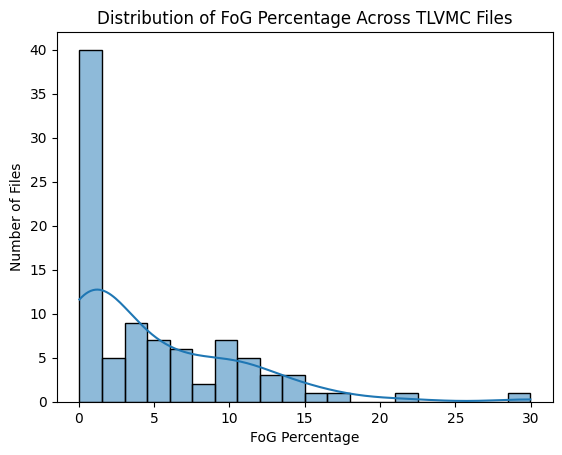

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(results_df["fog_percentage"], bins=20, kde=True)
plt.title("Distribution of FoG Percentage Across TLVMC Files")
plt.xlabel("FoG Percentage")
plt.ylabel("Number of Files")
plt.show()

In [13]:
summary

{'total_files': 91,
 'files_with_fog': np.int64(91),
 'files_without_fog': np.int64(0),
 'mean_fog_%': np.float64(5.0184596991885195),
 'max_fog_%': np.float64(29.984333876425616),
 'min_fog_%': np.float64(0.03618702980668508)}

In [14]:
results

[{'file': '02ea782681.csv',
  'fog_percentage': np.float64(0.07918628419896015),
  'has_fog': np.True_},
 {'file': '06414383cf.csv',
  'fog_percentage': np.float64(10.508132875143184),
  'has_fog': np.True_},
 {'file': '092b4c1819.csv',
  'fog_percentage': np.float64(2.6185262235848024),
  'has_fog': np.True_},
 {'file': '0c55be4384.csv',
  'fog_percentage': np.float64(9.404437333681615),
  'has_fog': np.True_},
 {'file': '0d7ab3a9f9.csv',
  'fog_percentage': np.float64(14.837226315514448),
  'has_fog': np.True_},
 {'file': '0eaac04f17.csv',
  'fog_percentage': np.float64(0.40835741140870657),
  'has_fog': np.True_},
 {'file': '0ec76d2d8e.csv',
  'fog_percentage': np.float64(0.6943004530231914),
  'has_fog': np.True_},
 {'file': '139f60d29b.csv',
  'fog_percentage': np.float64(1.0473326080928307),
  'has_fog': np.True_},
 {'file': '13a4fe5159.csv',
  'fog_percentage': np.float64(11.744249957720278),
  'has_fog': np.True_},
 {'file': '15508c7f41.csv',
  'fog_percentage': np.float64(0.59

In [18]:
folder_path = r"D:\tlvmc-parkinsons-freezing-gait-prediction\train\defog"

all_data = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(folder_path, file))

        df["fog"] = (
            ((df["StartHesitation"] == 1) | (df["Turn"] == 1) | (df["Walking"] == 1))
            & (df["Valid"] == 1)
            & (df["Task"] == 1)
        ).astype(int)

        all_data.append(df)

full_df = pd.concat(all_data)

In [19]:
full_df

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task,fog
0,0,-1.000000,0.044129,-0.250000,0,0,0,False,False,0
1,1,-1.000000,0.034431,-0.250000,0,0,0,False,False,0
2,2,-1.000000,0.031250,-0.250000,0,0,0,False,False,0
3,3,-1.000000,0.031250,-0.250000,0,0,0,False,False,0
4,4,-1.000000,0.031250,-0.250000,0,0,0,False,False,0
...,...,...,...,...,...,...,...,...,...,...
120027,120027,-0.962333,0.113288,-0.328300,0,0,0,False,False,0
120028,120028,-0.962351,0.109235,-0.324841,0,0,0,False,False,0
120029,120029,-0.956052,0.101676,-0.324484,0,0,0,False,False,0
120030,120030,-0.951245,0.097876,-0.322607,0,0,0,False,False,0


In [20]:
# Event Contribution Analysis
total_fog = full_df["fog"].sum()

print("StartHesitation:", full_df["StartHesitation"].sum() / total_fog)
print("Turn:", full_df["Turn"].sum() / total_fog)
print("Walking:", full_df["Walking"].sum() / total_fog)

StartHesitation: 0.0007290255698428367
Turn: 0.8565846318493775
Walking: 0.14364574023069285


In [ ]:
fog_values = []
nonfog_values = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(folder_path, file))

        labels = df[["fog"]]
        signals = df[[""]]

        fog_values.append(signals[labels == 1])
        nonfog_values.append(signals[labels == 0])

fog_df = pd.concat(fog_values)
nonfog_df = pd.concat(nonfog_values)

print("FoG Std:\n", fog_df.std())
print("\nNon-FoG Std:\n", nonfog_df.std())

In [24]:
fog_df

,0,1,2,3,4,5,6,7,8,9
72944,1139765,-202,960,425,445,888,464,-203,885,252
72945,1139781,-20,1127,386,536,907,333,-300,923,252
72946,1139796,-80,1058,475,672,981,232,-359,990,135
72947,1139812,-90,1156,534,836,888,151,-359,990,-19
72948,1139828,-50,1343,485,1081,888,181,-436,933,-58
...,...,...,...,...,...,...,...,...,...,...
155823,2434750,161,1029,207,-309,916,202,155,961,126
155824,2434765,262,1000,257,-254,907,191,165,923,155
155825,2434781,151,1019,188,-254,907,191,174,923,116
155826,2434796,171,1029,178,-254,935,171,184,914,145
